# Rapport : Projet Analyse de Données
### BAFALUY Inés - GAYRAUD Julien - .... Valentino
##### 4A MA - 2026

## INTRODUCTION

Créée en 2008, Spotify s’est imposée comme la plateforme de streaming audio la plus populaire au monde, avec 751 millions d’utilisateurs et plus de 100 millions de titres disponibles. Pour conserver sa position de référence, l’entreprise doit analyser les tendances musicales actuelles afin de proposer des services toujours plus innovants et personnalisés.

Recommandation de chansons, compréhension des évolutions temporelles des tendances, identification des facteurs de succès... voici les enjeux au cœur de ce projet. À travers l’analyse d’un échantillon de la base de données de Spotify, nous commencerons par prétraiter les données (1), puis nous étudierons l’évolution des tendances au fil du temps (2), les similarités inter- et intra-genres (3), les déterminants du succès musical (4), avant de concevoir des playlists et des recommandations adaptées (5).

À partir des résultats obtenus, nous formulerons des pistes d’action concrètes permettant à Spotify de renforcer durablement son attractivité et de demeurer une plateforme de référence, compétitive dans l’industrie du streaming musical.


## I. Exploration des données

#### IMPORT LIBRARIES

In [34]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.preprocessing import scale
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale


### 1. Base de données

Nous cherchons tout d'abord à avoir un aperçu géneral de nos données brutes en étudiants :
* la taille de nos données
* les variables étudiées

#### a) Aperçu des données brutes

In [35]:
# Load the latest version
data_initial = pd.read_csv('data/spotify_songs.csv')

print("=== Aperçu du jeu de données ===")
display(data_initial.head())

print("\n=== Dimensions du jeu de données ===")
print(f"Nombre de lignes : {data_initial.shape[0]}")
print(f"Nombre de variables : {data_initial.shape[1]}")

print("\n=== Types des variables ===")
display(data_initial.dtypes)

print("\n=== Valeurs manquantes ===")
display(data_initial.isnull().sum())

print("\n=== Statistiques descriptives ===")
display(data_initial.describe())

=== Aperçu du jeu de données ===


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052



=== Dimensions du jeu de données ===
Nombre de lignes : 32833
Nombre de variables : 23

=== Types des variables ===


track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object


=== Valeurs manquantes ===


track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


=== Statistiques descriptives ===


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


##### Variables Quantitatives

In [36]:
# Variables quantatives
quant_cols = data_initial.select_dtypes(include=['float64', 'int64']).columns
print(f"Nombre de variables quantitatives : {len(quant_cols)}")
print('Variables quantitatives :', list(quant_cols))

data_initial[quant_cols].describe()

Nombre de variables quantitatives : 13
Variables quantitatives : ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


##### Variables Qualitatives

In [37]:
### Variables qualitives
qual_cols = data_initial.columns.difference(quant_cols)
print(f"Nombre de variables qualitatives : {len(qual_cols)}")
print('Variables qualitatives :', list(qual_cols))

data_initial[qual_cols].describe()

Nombre de variables qualitatives : 10
Variables qualitatives : ['playlist_genre', 'playlist_id', 'playlist_name', 'playlist_subgenre', 'track_album_id', 'track_album_name', 'track_album_release_date', 'track_artist', 'track_id', 'track_name']


,playlist_genre,playlist_id,playlist_name,playlist_subgenre,track_album_id,track_album_name,track_album_release_date,track_artist,track_id,track_name
count,32833,32833,32833,32833,32833,32828,32833,32828,32833,32828
unique,6,471,449,24,22545,19743,4530,10692,28356,23449
top,edm,4JkkvMpVl4lSioqQjeAL0q,Indie Poptimism,progressive electro house,5L1xcowSxwzFUSJzvyMp48,Greatest Hits,2020-01-10,Martin Garrix,7BKLCZ1jbUBVqRi2FVlTVw,Poison
freq,6043,247,308,1809,42,139,270,161,10,22


Nous remarquons que les variables initialement quantitatives `mode` et `key` sont des entiers compris entre entre [0,11] et [0,1] respectivement. C'est pour cela, que nous allons plutôt les considérer des variables qualitatives. De même, de toutes les variables qualitatives affichées ci-dessus, nous n'allons considérer que `playlist_genre` ainsi que `playlist_subgenre` par leur faible nombre de modalités, 6 et 24 respectivement. Les autres variables qualitative, telles que `playlist_name` ou `playlist_id` ont plus de 450 modalités, ce qui les rend difficilement interprétables.

Nous allons ci-dessous définir les nouvelles listes de variables qualitatives et quantitatives.

In [38]:
# VAR QUANTITATIVES
try :
    quant_cols = quant_cols.drop(['mode', 'key'])  # on drop les variables 'mode' et 'key' qui sont des variables qualitatives encodées en numérique
except KeyError:
    pass

# VAR QUALITATIVES
# Nouvelle liste de variables qualitatives à convertir en type 'category' 
categorical_cols = [
    "playlist_genre", 
    "playlist_subgenre",
    "mode",
    "key"
]
for col in categorical_cols:
    data_initial[col] = pd.Categorical(data_initial[col], ordered=False)
qual_cols = categorical_cols

print(f"Variables quantitatives ({len(quant_cols)}) : {', '.join(quant_cols)}")
print(f"Variables qualitatives ({len(qual_cols)}) : {', '.join(qual_cols)}")

Variables quantitatives (11) : track_popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
Variables qualitatives (4) : playlist_genre, playlist_subgenre, mode, key



Nous allons baser notre étude sur les variables suivantes :
* 11 variables quantitatives : track_popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
* 4 variables qualitatives : playlist_genre, playlist_subgenre, mode, key


#### b ) Prétraitement des données

Afin de préparer nos données, nous allons suivre les étapes suivantes :
* Nettoyage des données
* Gaussianisation
* Détection des outliers
* Normalisation

##### Nettoyage des données

Dans un premier temps, nous allons éliminer les colonnes inutiles et non interprétables (id de la chanson et de la playlist), puis nous allons supprimer les colonnes incomplètes.

In [39]:
data_complete = data_initial.copy()

# Remove dumb columns and uncomplete lines 
print('=== Non-meaningful columns ===')
# remove identifiers if they exist
cols = ["track_album_id", "playlist_id", "track_id"]
print('Columns to drop:', cols)
data_complete.drop(columns=cols, errors='ignore', inplace=True)

print('')
print('=== Missing values ===')
print('Columns containing missing values are:', list(data_complete.columns[data_complete.isnull().sum()!=0]))

print('')
print('track_name - Rate of missing values: {:.2f}%'.format(data_complete['track_name'].isnull().sum()/data_complete.shape[0]*100))
print('track_artist - Rate of missing values: {:.2f}%'.format(data_complete['track_artist'].isnull().sum()/data_complete.shape[0]*100))
print('track_album_name - Rate of missing values: {:.2f}%'.format(data_complete['track_album_name'].isnull().sum()/data_complete.shape[0]*100))

print('We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.')

data_complete.dropna(subset=['track_name', 'track_artist', 'track_album_name'], inplace=True)

print('')
print('=== Checking ===')
print('Columns containing missing values are:', list(data_complete.columns[data_complete.isnull().sum()!=0]))


=== Non-meaningful columns ===
Columns to drop: ['track_album_id', 'playlist_id', 'track_id']

=== Missing values ===
Columns containing missing values are: ['track_name', 'track_artist', 'track_album_name']

track_name - Rate of missing values: 0.02%
track_artist - Rate of missing values: 0.02%
track_album_name - Rate of missing values: 0.02%
We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.

=== Checking ===
Columns containing missing values are: []


Comme la proportion de valeurs manquantes ne correspond qu'à 0.02%, on ne supprimera pas les colonnes qui ont certaines cases vides. Cependant, nous avons bien supprimer les colonnes `track_playlist_id`, `track_id` et `playlist_id`, qui nous apportent aucune information.

##### Gaussianisation

Dans cette partie, nous cherchons à gaussianiser nos variables quantitatives les plus asymétriques et avec des longues queues. Pour choisir objectivement quelles variables gaussianiser, nous allons séléctionner les variables qui ont une asymétrie supérieure à 1.5 en valeur absolue.

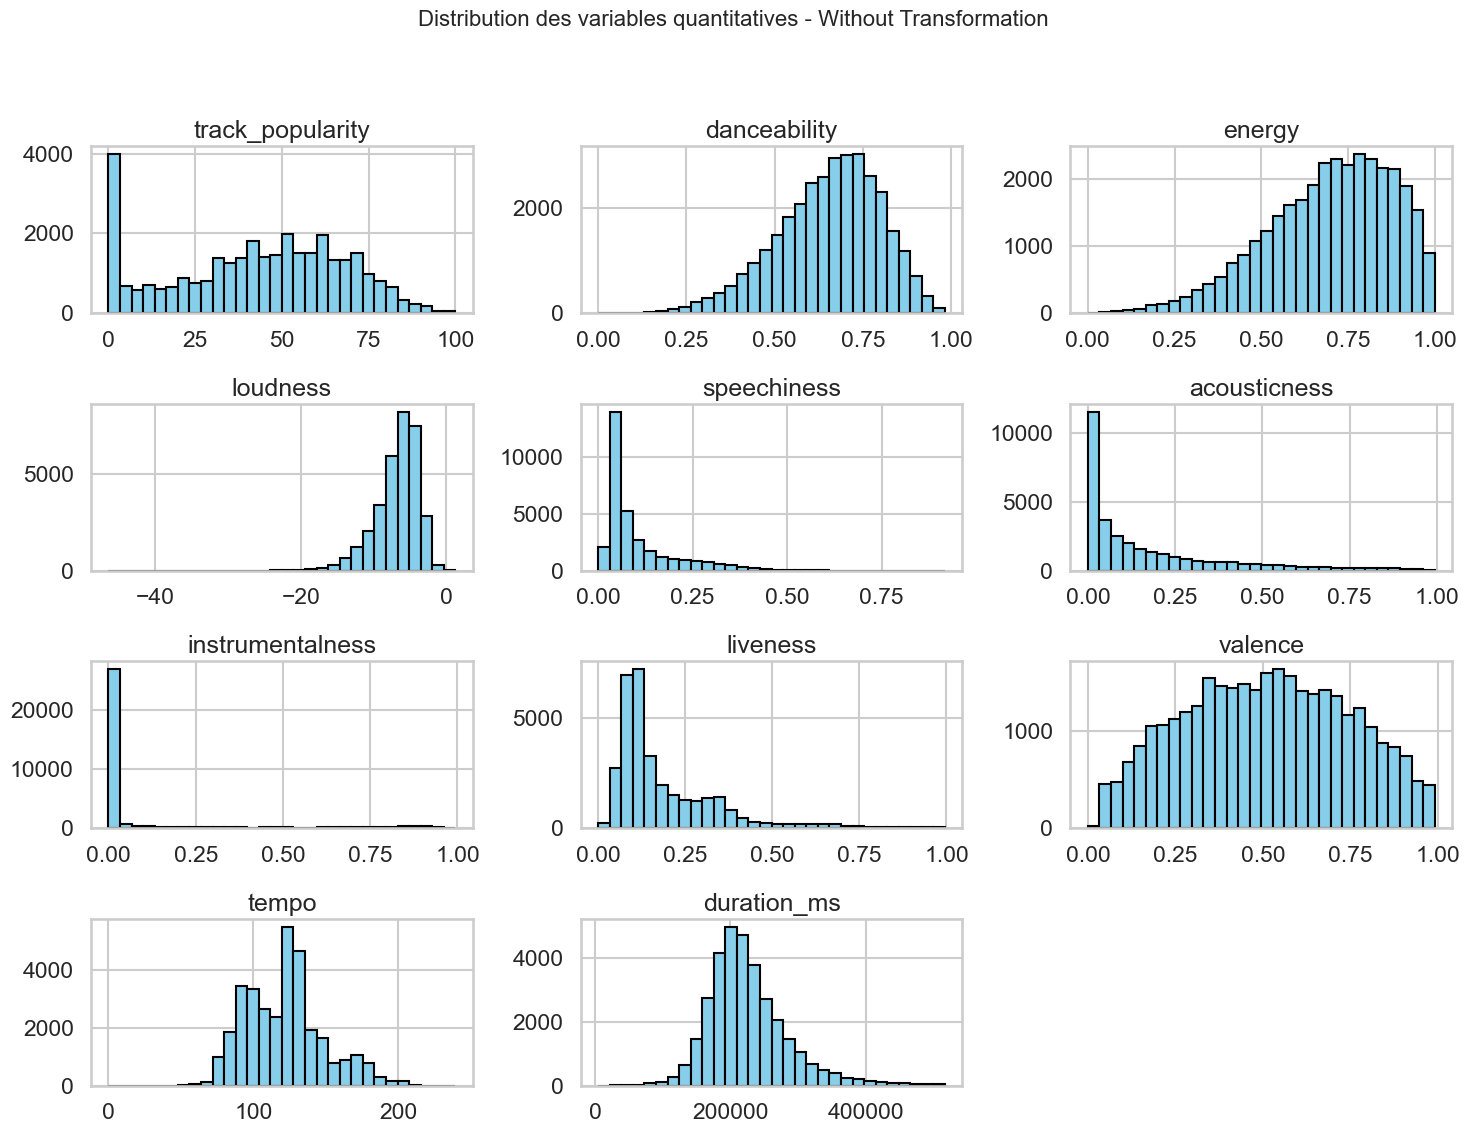

Skewness of quantitative variables:
track_popularity: -0.23
danceability: -0.50
energy: -0.64
loudness: -1.36
speechiness: 1.97
acousticness: 1.59
instrumentalness: 2.76
liveness: 2.08
valence: -0.01
tempo: 0.53
duration_ms: 1.15
Variables avec une asymétrie élevée: ['loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness']


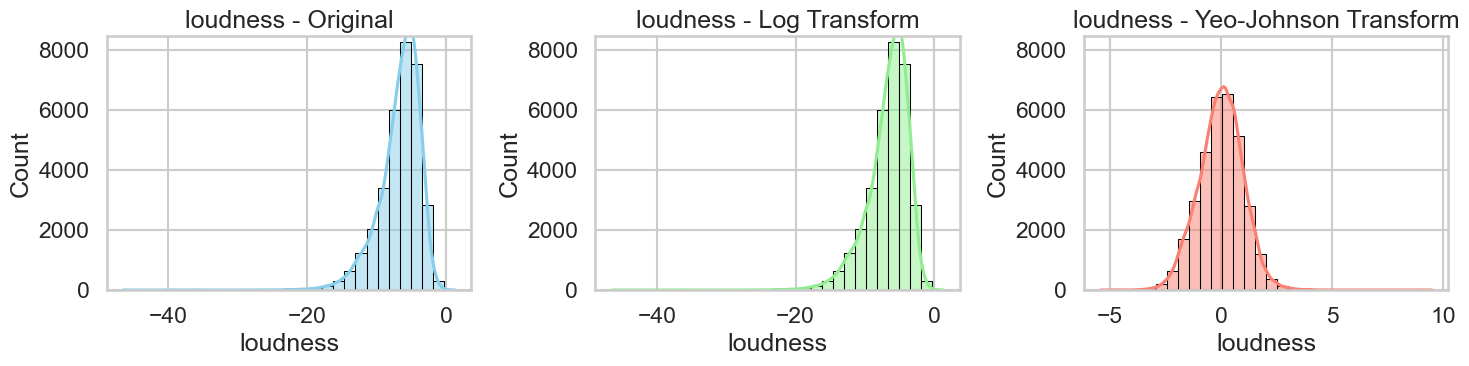

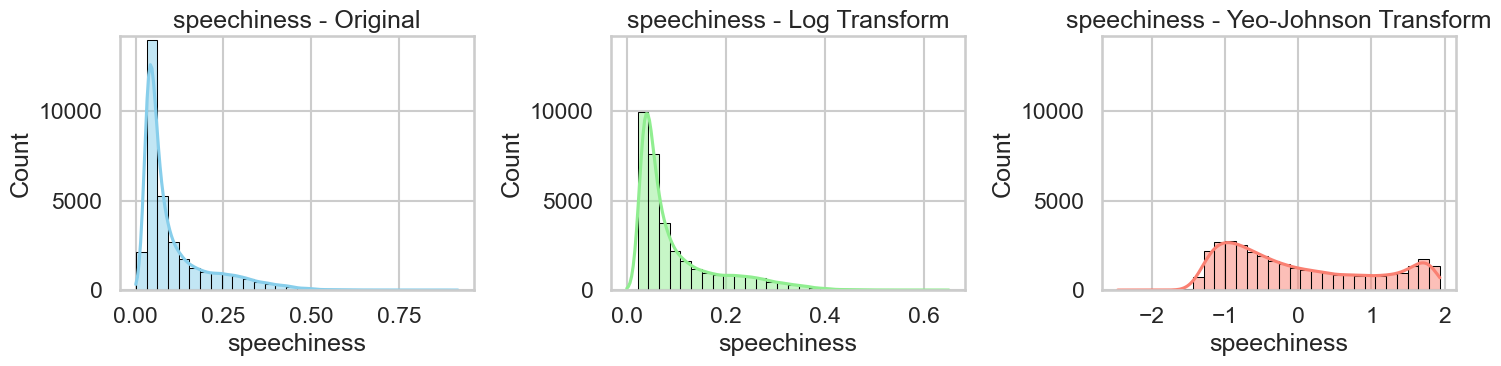

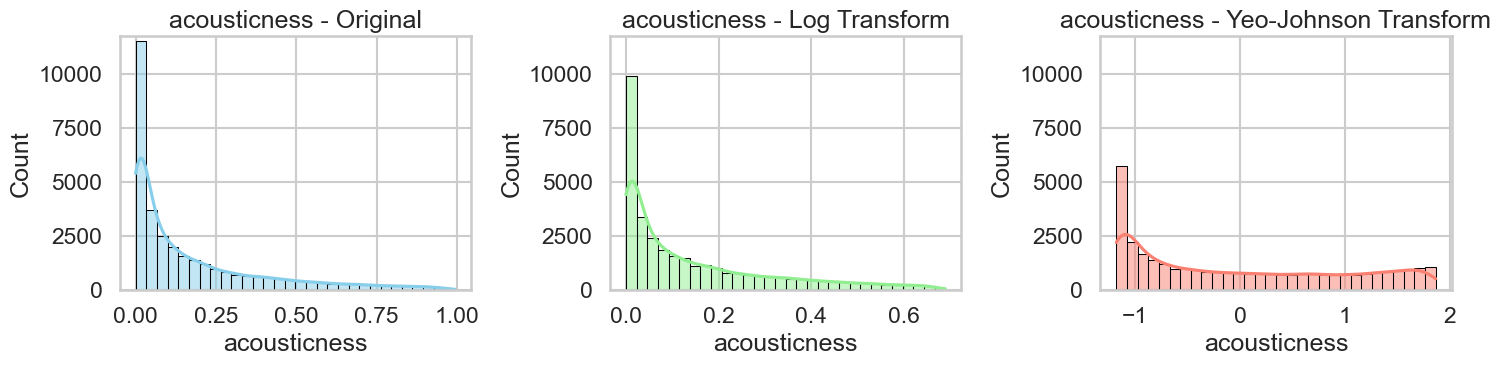

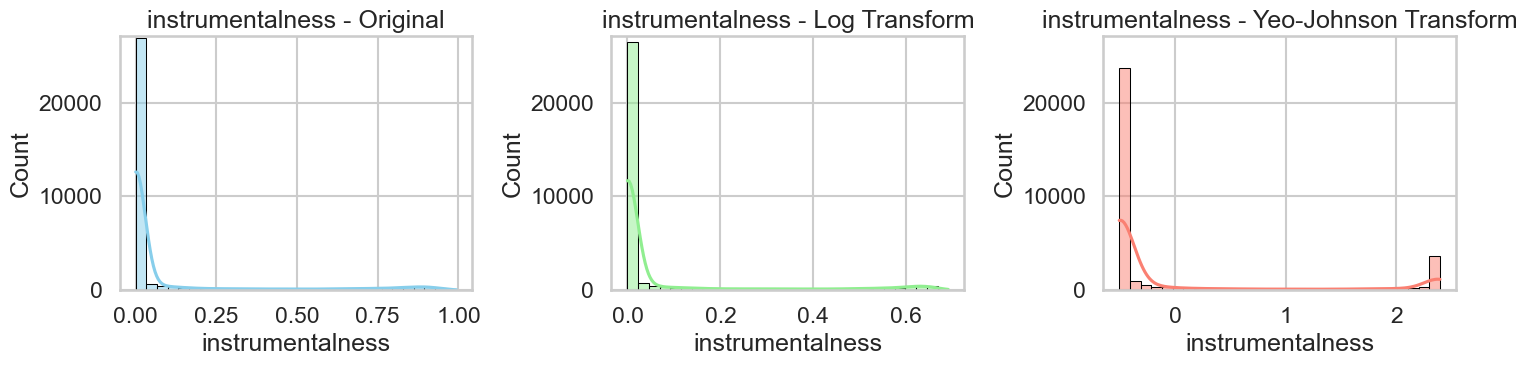

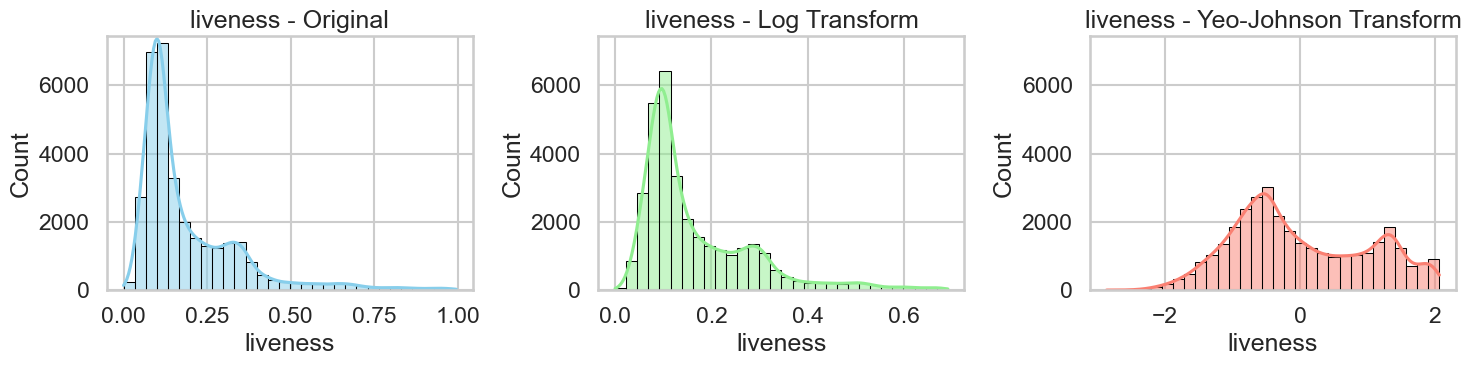

Skewness comparison after transformations:
                  Original       Log  Yeo-Johnson
loudness         -1.363997 -1.363997    -0.003220
speechiness       1.967659  1.719290     0.509308
acousticness      1.594553  1.296568     0.403712
instrumentalness  2.759187  2.607333     1.748006
liveness          2.076842  1.664519     0.304086


In [40]:
from sklearn.preprocessing import PowerTransformer

data_to_transform = data_complete.copy()

# histogrammes avant transformation
data_to_transform[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distribution des variables quantitatives - Without Transformation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# calcul de la skewness/Asymétrie
# --> on cherche ici à identifier les variables quantitatives qui ont une forte asymétrie (skewness) pour les transformer ensuite et les rendre plus gaussiennes
print('Skewness of quantitative variables:')
var_to_gauss = []
for col in quant_cols:
    skewness = data_to_transform[col].skew()
    print(f"{col}: {skewness:.2f}")
    if abs(skewness) > 1.3:
        var_to_gauss.append(col)

print(f"Variables avec une asymétrie élevée: {var_to_gauss}")

# LOG
data_gauss_log = data_to_transform.copy()
for col in ["speechiness", "acousticness", "instrumentalness", "liveness"]:
    if col in data_gauss_log.columns:
        data_gauss_log[col] = np.log1p(data_gauss_log[col])

# YEO-JOHNSON : accepte aussi 0 et négatifs
data_gauss_yeo = data_to_transform.copy()
if var_to_gauss:
    pt_yeo = PowerTransformer(method="yeo-johnson")
    data_gauss_yeo[var_to_gauss] = pt_yeo.fit_transform(data_gauss_yeo[var_to_gauss])

# visualisation
for col in var_to_gauss:
    
    # Compute common y-axis limit
    counts_original, _ = np.histogram(data_to_transform[col].dropna(), bins=30)
    counts_log, _ = np.histogram(data_gauss_log[col].dropna(), bins=30)
    counts_yeo, _ = np.histogram(data_gauss_yeo[col].dropna(), bins=30)

    max_count = max(
        counts_original.max(),
        counts_log.max(),
        counts_yeo.max()
    ) + 200  # add some margin

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.histplot(
        data_to_transform[col],
        bins=30,
        kde=True,
        color='skyblue',
        edgecolor='black',
        ax=axes[0]
    )
    axes[0].set_title(f"{col} - Original")
    axes[0].set_ylim(0, max_count)

    sns.histplot(
        data_gauss_log[col],
        bins=30,
        kde=True,
        color='lightgreen',
        edgecolor='black',
        ax=axes[1]
    )
    axes[1].set_title(f"{col} - Log Transform")
    axes[1].set_ylim(0, max_count)


    sns.histplot(
        data_gauss_yeo[col],
        bins=30,
        kde=True,
        color='salmon',
        edgecolor='black',
        ax=axes[2]
    )
    axes[2].set_title(f"{col} - Yeo-Johnson Transform")
    axes[2].set_ylim(0, max_count)

    plt.tight_layout()
    plt.show()

# tableau comparatif
skewness_comparison = pd.DataFrame({
    "Original": data_to_transform[var_to_gauss].skew(),
    "Log": data_gauss_log[var_to_gauss].skew(),
    "Yeo-Johnson": data_gauss_yeo[var_to_gauss].skew()
})


print("Skewness comparison after transformations:")
print(skewness_comparison)


Nous observons une amélioration significative de la symétrie de nos variables quantitatives étudiées après transformation, notamment avec la transformation de Yeo-Johnson. Nous allons donc conserver les valeurs de ces variables transformées dans une nouvelle base de données appelée `data_gauss`, en renommant les colonnes concernées. 

In [41]:
data_gauss = data_gauss_yeo.copy()

# Create rename dictionary only for transformed variables
rename_dict = {col: col + "_yeo" for col in var_to_gauss}

# Rename columns
data_gauss = data_gauss.rename(columns=rename_dict)

quant_cols_gauss = [col + "_yeo" for col in var_to_gauss if col in var_to_gauss]
quant_cols_gauss += [col for col in quant_cols if col not in var_to_gauss]

print(f"Quantitative columns after transformation: {quant_cols_gauss}")
print(f"Variables: {data_gauss.columns.tolist()}")

Quantitative columns after transformation: ['loudness_yeo', 'speechiness_yeo', 'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'track_popularity', 'danceability', 'energy', 'valence', 'tempo', 'duration_ms']
Variables: ['track_name', 'track_artist', 'track_popularity', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness_yeo', 'mode', 'speechiness_yeo', 'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'valence', 'tempo', 'duration_ms']


##### Détection d'outliers

Dans cette partie, nous cherchons à détecter et supprimer les outliers qui pourraient nuire à la justesse de nos résultants.

In [42]:
# Outlier detection using IQR method with different k values

# Observe quantity of outliers for every variable
k=1.5
Q1 = data_gauss[quant_cols_gauss].quantile(0.25)
Q3 = data_gauss[quant_cols_gauss].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - k * IQR
upper = Q3 + k * IQR

removed = (
    (data_gauss[quant_cols_gauss] < lower) |
    (data_gauss[quant_cols_gauss] > upper)
).mean()

print(f"\nk = {k}")
print((removed * 100).round(2).astype(str) + " %")

# Variables with more than 5% outliers
high_outliers = removed[removed > 0.03]

print("\nVariables with > 3% outliers:")
if len(high_outliers) == 0:
    print("None")
else:
    print((high_outliers * 100).round(2).astype(str) + " %")



# Different values of k :
print("\nTotal number of removed rows for different values of k")
var_to_remove_outliers = quant_cols_gauss.copy()
var_to_remove_outliers.remove("instrumentalness_yeo")
var_to_remove_outliers.remove("duration_ms")

for k in [1, 1.5, 1.7, 1.8, 2, 2.3, 2.5]:
    Q1 = data_gauss[var_to_remove_outliers].quantile(0.25)
    Q3 = data_gauss[var_to_remove_outliers].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    mask = (
        (data_gauss[var_to_remove_outliers] >= lower) &
        (data_gauss[var_to_remove_outliers] <= upper)
    ).all(axis=1)

    removed_rows = 1 - mask.mean()

    print(f"k={k}: {removed_rows:.2%} rows removed")




k = 1.5
loudness_yeo             1.07 %
speechiness_yeo           0.0 %
acousticness_yeo          0.0 %
instrumentalness_yeo    21.27 %
liveness_yeo              0.0 %
track_popularity          0.0 %
danceability             0.89 %
energy                   0.84 %
valence                   0.0 %
tempo                    1.74 %
duration_ms              4.23 %
dtype: str

Variables with > 3% outliers:
instrumentalness_yeo    21.27 %
duration_ms              4.23 %
dtype: str

Total number of removed rows for different values of k
k=1: 16.52% rows removed
k=1.5: 4.07% rows removed
k=1.7: 2.31% rows removed
k=1.8: 1.59% rows removed
k=2: 0.73% rows removed
k=2.3: 0.16% rows removed
k=2.5: 0.11% rows removed


Les outliers ont été identifiés à l’aide de la méthode de l’IQR, qui consiste à identifier les valeurs aberrantes en utilisant l’intervalle interquartile (Q3 − Q1) et en définissant des bornes au-delà desquelles les observations sont considérées comme extrêmes. 

On observe que variable `instrumentalness_yeo`, ainsi que la variable `duration_ms` présentent naturellement une distribution très asymétrique, ce qui explique le nombre plus élevé de valeurs extrêmes observées. Nous n'allons pas appliquer ce filtre pour ces deux variables, car on perdrait trop d'informations.

Le paramètre k contrôle la sévérité de la détection. Après comparaison de plusieurs valeurs de k, on choisi la valeur k = 1.7, car elle permet de limiter la suppression des données (environ 2 % des observations).


=== OUTLIER REMOVAL SUMMARY ===

Before outlier removal: 32828 rows
After outlier removal: 32070 rows
Rows removed: 758 (2.31%)


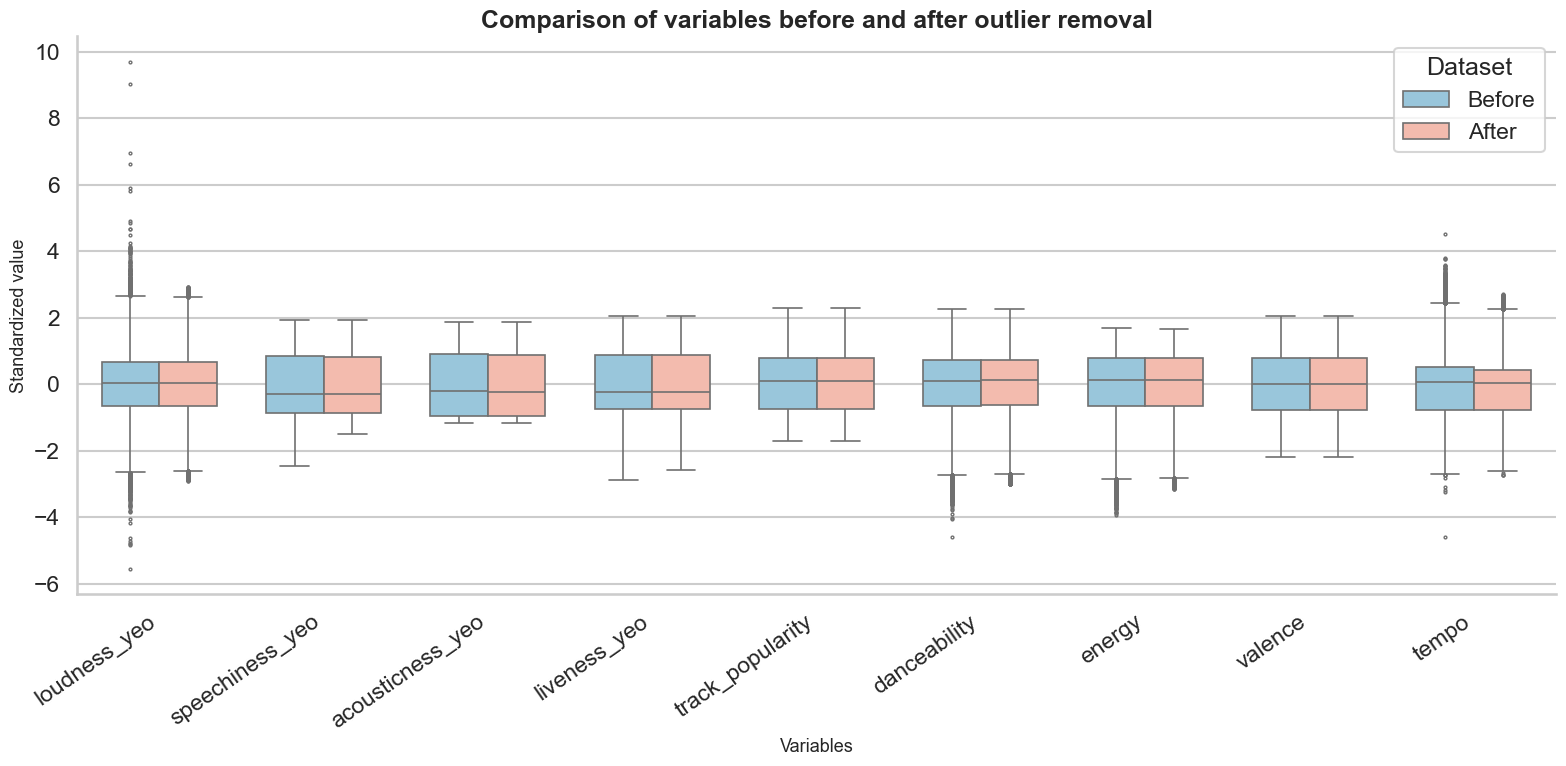

In [43]:
## BOXPLOTS


# Removing outliers with the IQR method
k = 1.7

Q1 = data_gauss[var_to_remove_outliers].quantile(0.25)
Q3 = data_gauss[var_to_remove_outliers].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - k * IQR
upper = Q3 + k * IQR

mask = (
    (data_gauss[var_to_remove_outliers] >= lower) &
    (data_gauss[var_to_remove_outliers] <= upper)
).all(axis=1)

data_without_outliers = data_gauss[mask]

removed_pct = 1 - mask.mean()


# Print summary statistics before and after outlier removal
print("\n=== OUTLIER REMOVAL SUMMARY ===")
print(f"\nBefore outlier removal: {len(data_gauss)} rows")
print(f"After outlier removal: {len(data_without_outliers)} rows")
print(f"Rows removed: {len(data_gauss) - len(data_without_outliers)} ({(len(data_gauss) - len(data_without_outliers))/len(data_gauss)*100:.2f}%)")



# COMPARISON PLOT

# Long format: before / after
df_before = data_gauss[var_to_remove_outliers].copy()
df_before["dataset"] = "Before"

df_after = data_without_outliers[var_to_remove_outliers].copy()
df_after["dataset"] = "After"

df_comb = pd.concat([df_before, df_after], ignore_index=True)

# standardize for visualization only
features = var_to_remove_outliers
scaler = StandardScaler()
df_comb[features] = scaler.fit_transform(df_comb[features])

# reshape
df_comb = df_comb.melt(
    id_vars="dataset",
    var_name="feature",
    value_name="value"
)

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(16, 8))

ax = sns.boxplot(
    data=df_comb,
    x="feature",
    y="value",
    hue="dataset",
    palette={"Before": "#8ecae6", "After": "#ffb4a2"},
    width=0.7,
    linewidth=1.2,
    fliersize=2
)

ax.set_title("Comparison of variables before and after outlier removal", fontsize=18, weight="bold")
ax.set_xlabel("Variables", fontsize=13)
ax.set_ylabel("Standardized value", fontsize=13)

plt.xticks(rotation=35, ha="right")
plt.legend(title="Dataset", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

Les boxplots montrent une diminution du nombre de valeurs extrêmes après le traitement des outliers, ainsi qu’une légère réduction de la dispersion pour certaines variables comme `tempo`ou `danceability`. Néanmoins, les médianes restent globalement stables, ce qui indique que la suppression des observations aberrantes a permis d’améliorer la robustesse des données sans altérer de manière significative les caractéristiques principales des distributions.


##### Normalisation

In [44]:
data_centered = data_without_outliers.copy()
data_centered[quant_cols_gauss] = StandardScaler().fit_transform(data_centered[quant_cols_gauss])

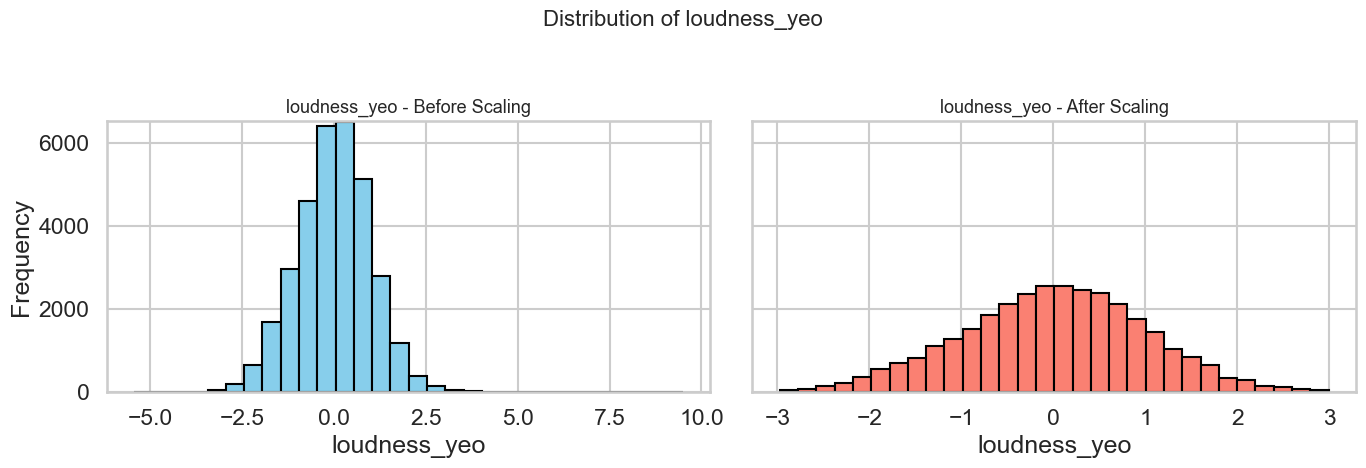

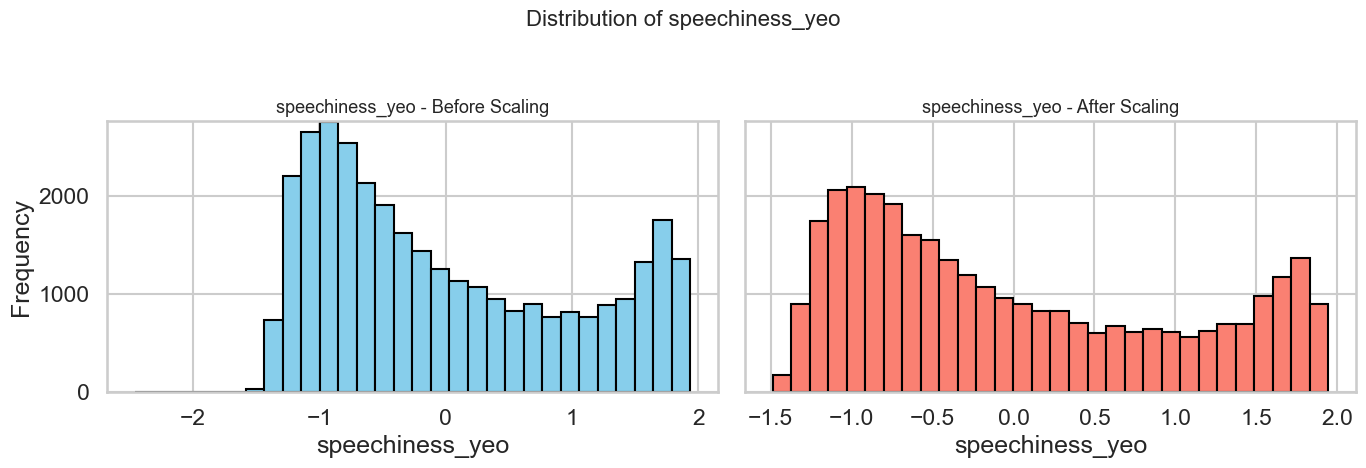

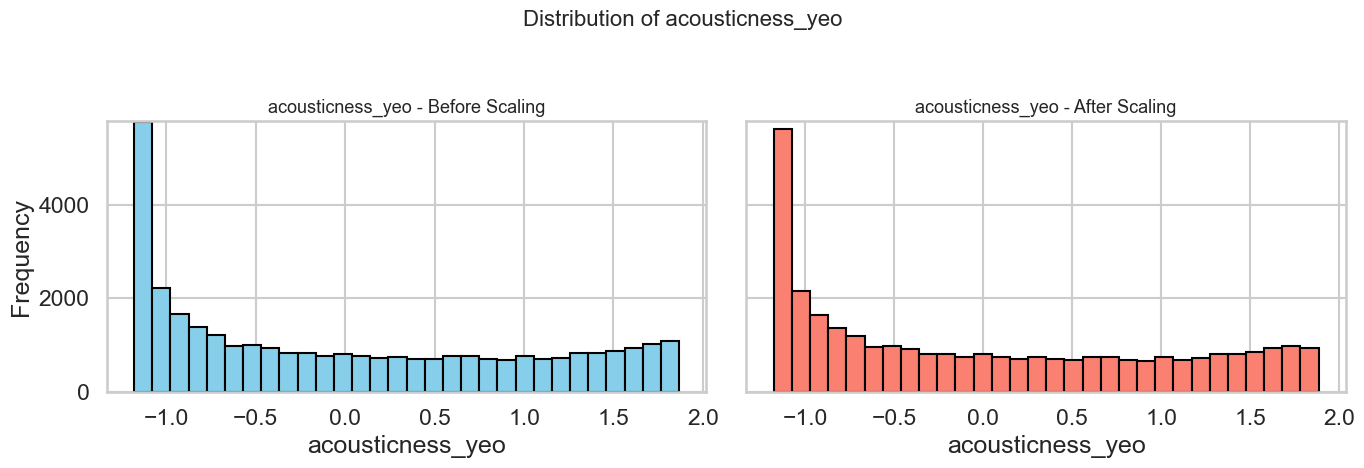

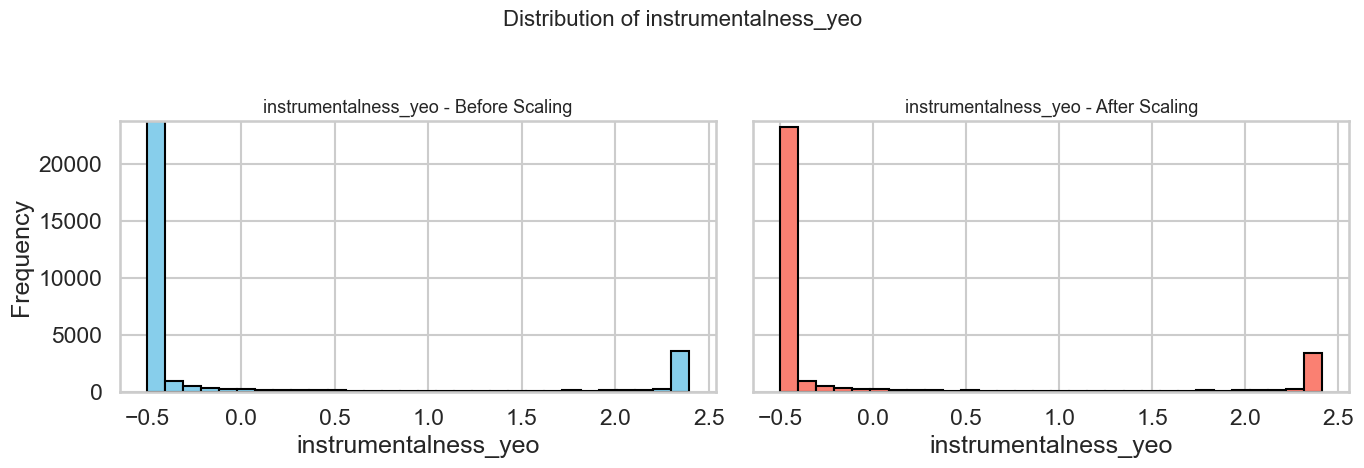

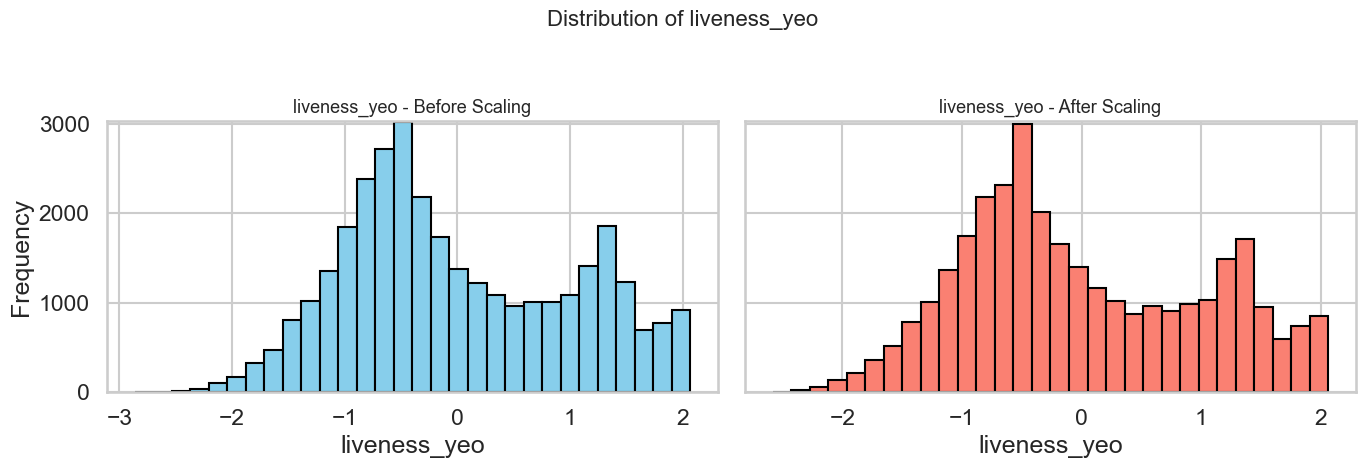

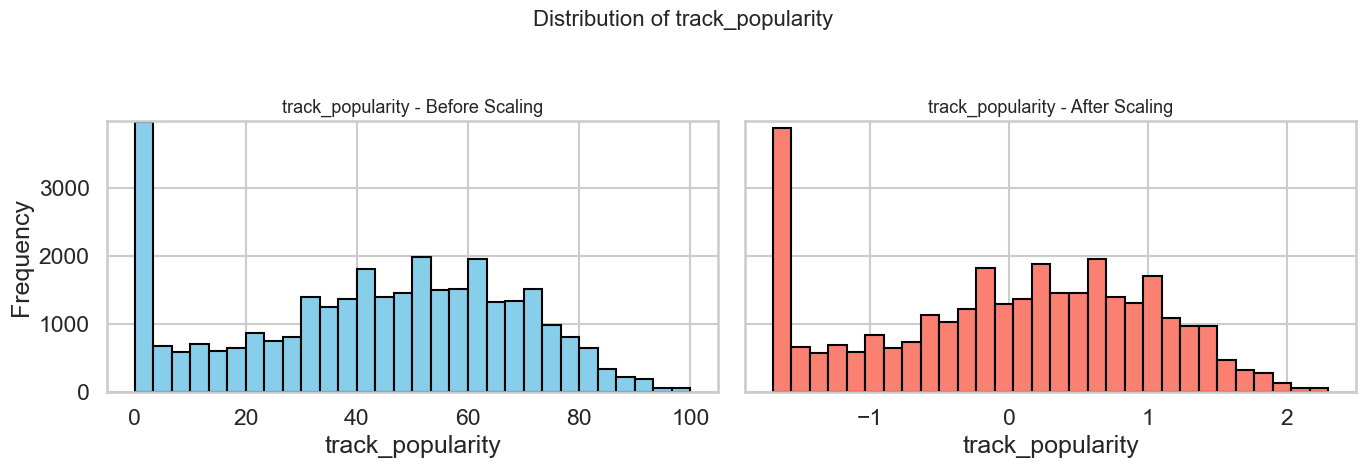

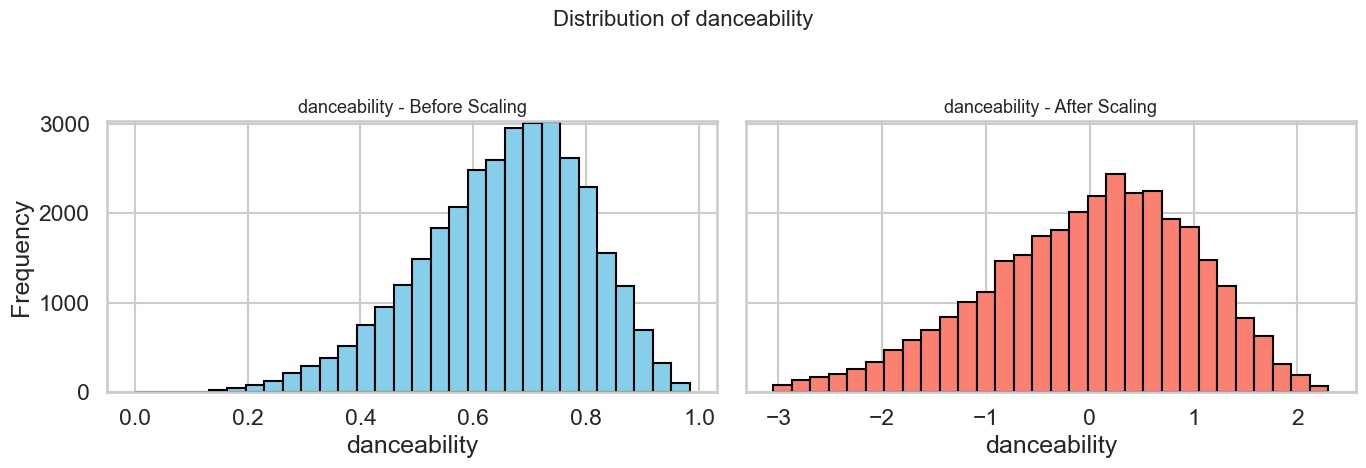

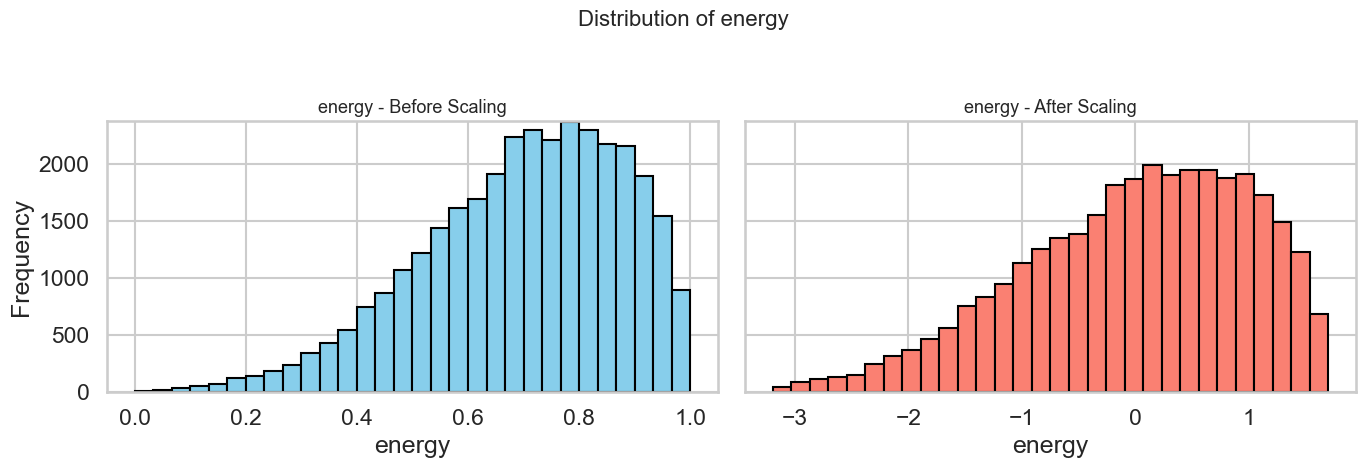

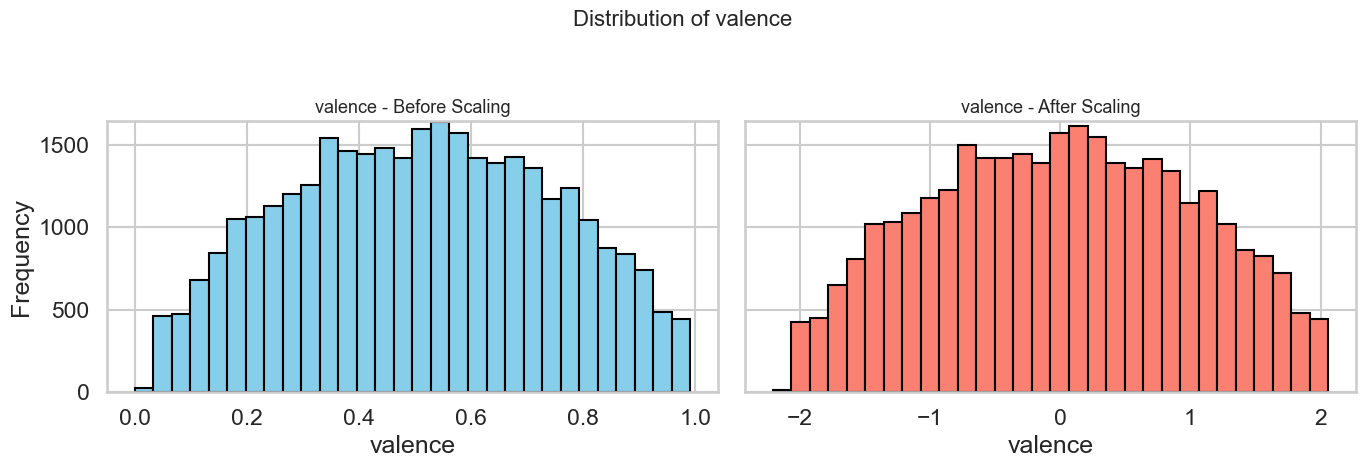

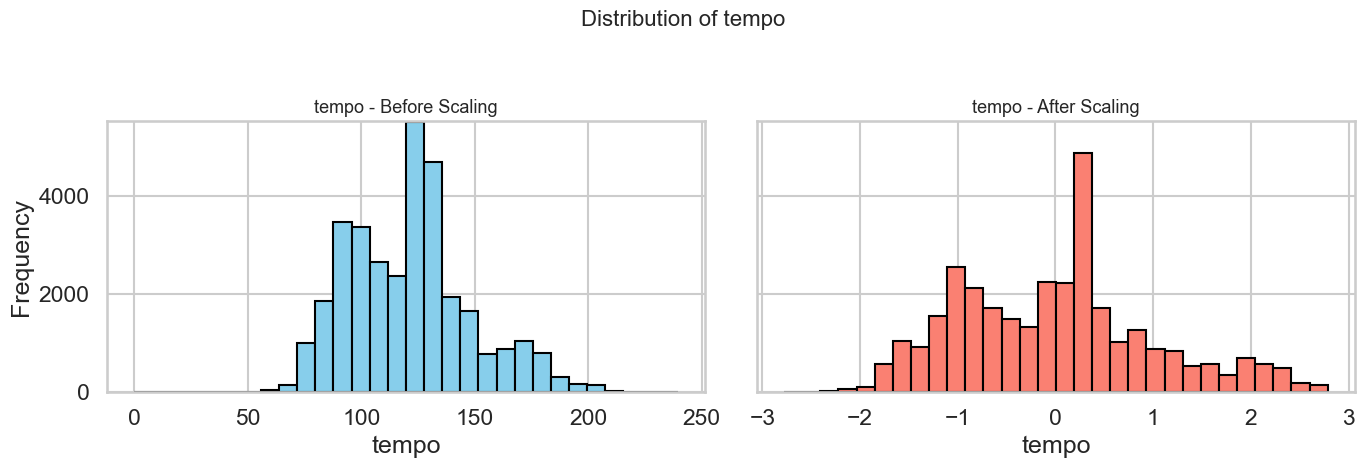

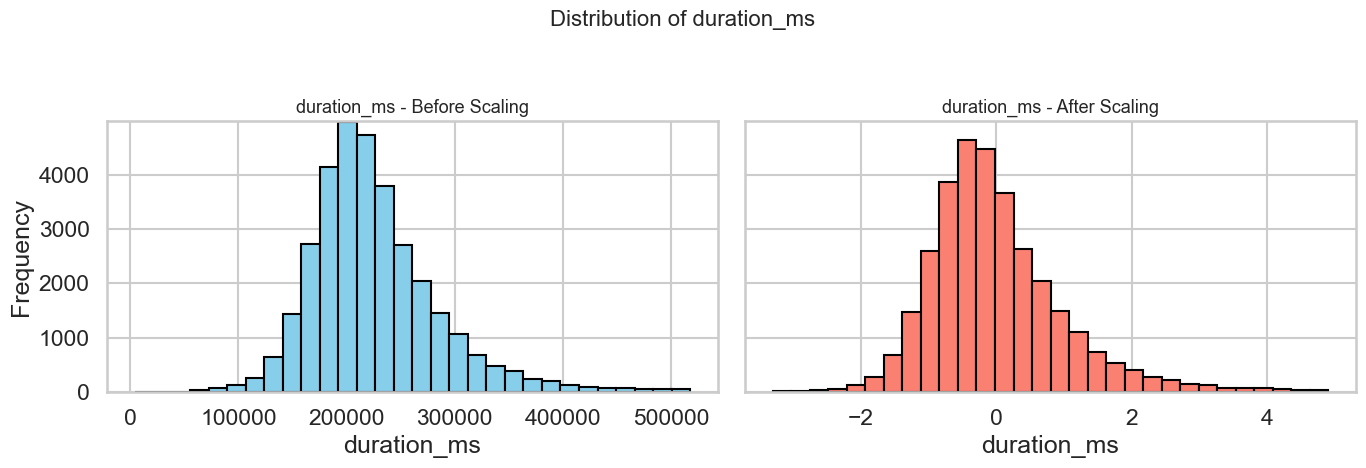

In [45]:
for col in quant_cols_gauss:
    
    # Compute common y-axis limit
    counts_gauss, _ = np.histogram(data_gauss[col].dropna(), bins=30)
    counts_centered, _ = np.histogram(data_centered[col].dropna(), bins=30)

    max_count = max(counts_gauss.max(), counts_centered.max()) + 5  # small margin

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Before scaling
    axes[0].hist(
        data_gauss[col].dropna(),
        bins=30,
        color='skyblue',
        edgecolor='black'
    )
    axes[0].set_title(f"{col} - Before Scaling", fontsize=13)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].set_ylim(0, max_count)

    # After scaling
    axes[1].hist(
        data_centered[col].dropna(),
        bins=30,
        color='salmon',
        edgecolor='black'
    )
    axes[1].set_title(f"{col} - After Scaling", fontsize=13)
    axes[1].set_xlabel(col)
    axes[1].set_ylim(0, max_count)

    plt.suptitle(f"Distribution of {col}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

##### Données prétraitées

Nous pouvons donc définir le dataframe `data` comme notre jeu de données propre après le prétraitement effectué ci-dessus, que nous utiliserons tout au long de notre étude. Le jeu de données final contient N observations et P variables quantitatives centrées et réduites. L’analyse descriptive montre que les variables sont désormais standardisées, avec une moyenne proche de 0 et une dispersion comparable entre les différentes caractéristiques.

Voici les différentes notations introduites : 

Bases de données (dataframes) :
* data_initial :  données importées brutes
* data_complete : data_initial mais sans les colonnes inutiles et les colonnes significativement vides
* data_gauss : data_complete mais avec les transformations pour gaussianiser les variables les plus asymétriques
* data_without_outliers : data_gauss mais en enlevant des données aberrantes (2% des données totales)
* data_centered : data_without_outliers mais centre-réduit
* data : dataframe avec toutes les modifications ci-dessus

Variables (listes) :
* qual_cols : liste des variables qualitatives
* quant_cols : liste des variables quantitatives non transformées
* quant_cols_gauss : liste des variables quantitatives après transformation sur les variables les plus asymétriques
* var_to_gauss : liste des variables quantitatives transformées



In [46]:
# Copie du jeu de données centré
data = data_centered.copy()

print("=== Aperçu du jeu de données ===")
display(data.head())

print("\n=== Dimensions du jeu de données ===")
print(f"Nombre de lignes : {data.shape[0]}")
print(f"Nombre de variables : {data.shape[1]}")

print("\n=== Types des variables ===")
display(data.dtypes)

print("\n=== Valeurs manquantes ===")
display(data.isnull().sum())

print("\n=== Statistiques descriptives ===")
display(data.describe())

=== Aperçu du jeu de données ===


,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness_yeo,mode,speechiness_yeo,acousticness_yeo,instrumentalness_yeo,liveness_yeo,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.938467,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,pop,dance pop,0.632935,1.223901,6,1.875621,1,-0.380608,-0.015490,-0.500338,-1.240353,0.023140,0.076864,-0.526017
1,Memories - Dillon Francis Remix,Maroon 5,0.978440,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.477207,0.648108,11,0.532599,1,-0.970760,-0.290401,-0.336678,1.381027,0.776228,-0.782359,-1.066234
2,All the Time - Don Diablo Remix,Zara Larsson,1.098359,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.116202,1.309415,1,1.344702,0,-0.020391,-0.221499,-0.499404,-0.480337,0.431959,0.153659,-0.830752
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.698628,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.420579,1.303714,7,1.141469,1,0.472041,-0.784073,-0.499960,0.555098,-1.013970,0.073749,-0.957145
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,1.058386,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,-0.060762,0.750724,1,0.673179,1,-1.015529,-0.212823,-0.500338,-0.906930,0.913936,0.152413,-0.621816



=== Dimensions du jeu de données ===
Nombre de lignes : 32070
Nombre de variables : 20

=== Types des variables ===


track_name                       str
track_artist                     str
track_popularity             float64
track_album_name                 str
track_album_release_date         str
playlist_name                    str
playlist_genre              category
playlist_subgenre           category
danceability                 float64
energy                       float64
key                         category
loudness_yeo                 float64
mode                        category
speechiness_yeo              float64
acousticness_yeo             float64
instrumentalness_yeo         float64
liveness_yeo                 float64
valence                      float64
tempo                        float64
duration_ms                  float64
dtype: object


=== Valeurs manquantes ===


track_name                  0
track_artist                0
track_popularity            0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness_yeo                0
mode                        0
speechiness_yeo             0
acousticness_yeo            0
instrumentalness_yeo        0
liveness_yeo                0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


=== Statistiques descriptives ===


,track_popularity,danceability,energy,loudness_yeo,speechiness_yeo,acousticness_yeo,instrumentalness_yeo,liveness_yeo,valence,tempo,duration_ms
count,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04
mean,1.417984e-17,-3.119564e-16,1.063488e-17,-1.417984e-17,4.608447e-17,-1.772480e-17,7.089918e-17,1.063488e-17,1.843379e-16,-3.615858e-16,7.089918e-18
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-1.699754e+00,-3.047907e+00,-3.194317e+00,-2.973018e+00,-1.487743e+00,-1.178956e+00,-5.003384e-01,-2.583303e+00,-2.205958e+00,-2.778310e+00,-3.302553e+00
25%,-7.404013e-01,-6.553596e-01,-6.745073e-01,-6.590589e-01,-8.559474e-01,-9.633294e-01,-5.003384e-01,-7.481111e-01,-7.729820e-01,-7.835666e-01,-6.394904e-01
50%,9.903269e-02,1.091230e-01,1.179215e-01,2.721263e-02,-2.836815e-01,-2.186024e-01,-4.997291e-01,-2.449897e-01,1.022971e-02,6.239738e-02,-1.670486e-01
75%,7.785745e-01,7.320348e-01,7.906309e-01,6.804577e-01,8.354770e-01,8.908785e-01,-3.238973e-01,8.762251e-01,7.848347e-01,4.669402e-01,4.648843e-01
max,2.297550e+00,2.296393e+00,1.697078e+00,2.990774e+00,1.944208e+00,1.886324e+00,2.414456e+00,2.061093e+00,2.058630e+00,2.786784e+00,4.901620e+00


### 2. Etude des variables

### 3. Etude des corrélations entre variables

## II. Analyse des tendences (TEMPS)

## III. Analyse des genres

## IV. Analyse des facteurs de succès

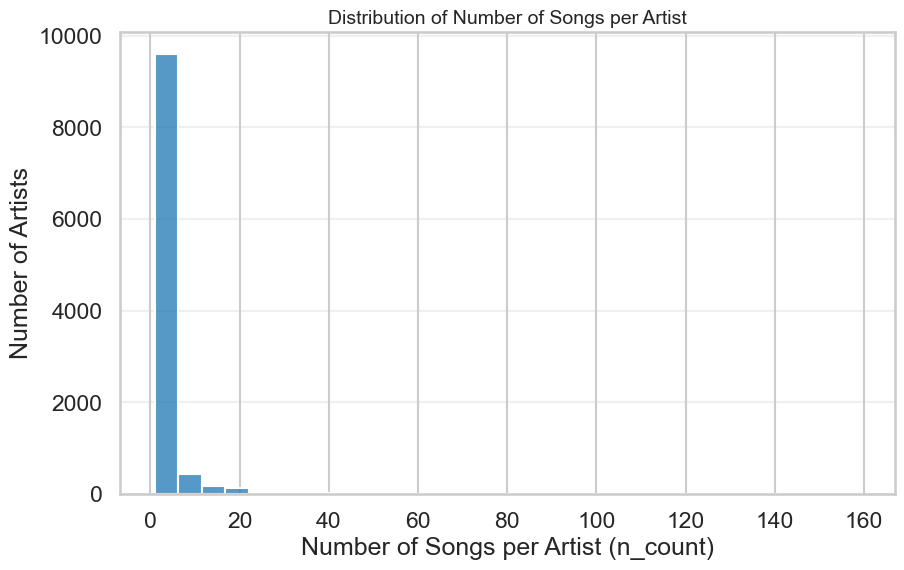

In [47]:
artist_counts = (
    data
    .groupby('track_artist')
    .size()
    .reset_index(name='n_count')
)

plt.figure(figsize=(10,6))

sns.histplot(
    data=artist_counts,
    x='n_count',
    bins=30,
    kde=False
)

plt.title(
    "Distribution of Number of Songs per Artist",
    fontsize=14
)

plt.xlabel("Number of Songs per Artist (n_count)")
plt.ylabel("Number of Artists")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [48]:
artists_50plus = (
    data
    .groupby('track_artist')
    .size()
    .reset_index(name='n_count')
    .query('n_count > 50')
)


# Popularity comparison
mean_pop_50plus = (
    data[
        data['track_artist'].isin(
            artists_50plus['track_artist']
        )
    ]['track_popularity']
    .mean()
)

mean_pop_all = data['track_popularity'].mean()

print("Mean popularity — artists with >50 songs:", round(mean_pop_50plus, 2))
print("Mean popularity — all artists:", round(mean_pop_all, 2))
print("Difference:", round(mean_pop_50plus - mean_pop_all, 2))

Mean popularity — artists with >50 songs: 0.29
Mean popularity — all artists: 0.0
Difference: 0.29


In [49]:
data_artist = data.copy()


data_artist['release_year'] = pd.to_datetime(
    data['track_album_release_date'],
    errors='coerce'
).dt.year

# Define hit variable
threshold = 0.7
data_artist['is_hit'] = data_artist['track_popularity'] >= threshold

# -------------------------
# Helper functions
# -------------------------

def genre_entropy(group):
    proportions = group['playlist_genre'].value_counts(normalize=True)
    return -(proportions * np.log(proportions)).sum()


def genre_dominance(group):
    return group['playlist_genre'].value_counts(normalize=True).max()


def popularity_trend(group):
    if group['release_year'].nunique() < 2:
        return np.nan
    return np.corrcoef(
        group['release_year'],
        group['track_popularity']
    )[0, 1]


# -------------------------
# Create artist features
# -------------------------

artist_features = (
    data_artist
    .groupby('track_artist')
    .apply(lambda g: pd.Series({

        # Productivity
        'n_songs': (len(g)),

        # Popularity
        'avg_popularity': g['track_popularity'].mean(),
        'popularity_variability': g['track_popularity'].std(),
        'hit_rate': g['is_hit'].mean(),

        # Trend
        'popularity_trend': popularity_trend(g),

        # Genre diversity
        'genre_heterogeneity': genre_entropy(g),
        'genre_dominance': genre_dominance(g),
        'n_genres': (g['playlist_genre'].nunique()),
        'genre_switch_rate': (
            g['playlist_genre']
            .shift()
            .ne(g['playlist_genre'])
            .mean()
        ),
        'genre_balance': (
            g['playlist_genre']
            .value_counts(normalize=True)
            .std()
        ),

        # Consistency
        'career_length': g['release_year'].max() - g['release_year'].min(),
        'songs_per_year': len(g) / (g['release_year'].max() - g['release_year'].min() + 1),
        'release_burstiness': (
            g['release_year']
            .value_counts()
            .std()
        ),
        'release_regularization': (
            g['release_year']
            .diff()
            .std()
        ),

    }))
    .reset_index()
)


c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, me

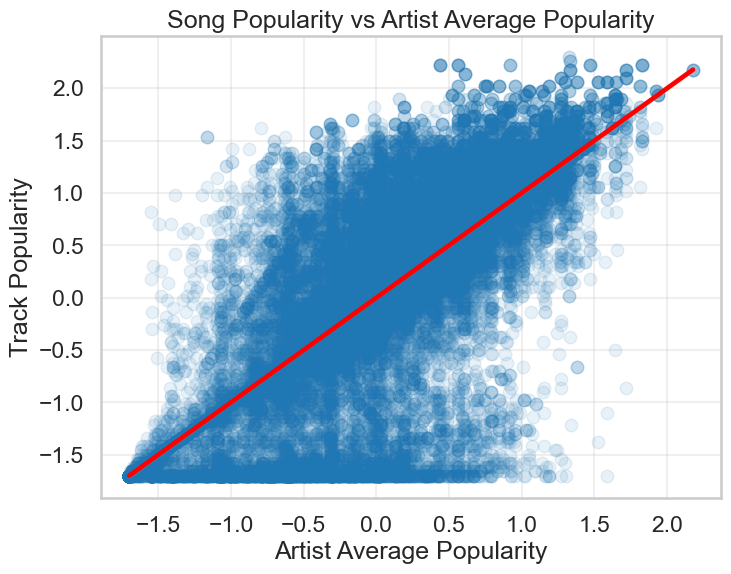

In [50]:
data_with_artist = data.merge(
    artist_features[['track_artist', 'avg_popularity']],
    on='track_artist',
    how='left'
)


plt.figure(figsize=(8,6))

sns.regplot(
    data=data_with_artist,
    x='avg_popularity',
    y='track_popularity',
    scatter_kws={"alpha": 0.1},
    line_kws={"color": "red"}
)

plt.title("Song Popularity vs Artist Average Popularity")
plt.xlabel("Artist Average Popularity")
plt.ylabel("Track Popularity")

plt.grid(alpha=0.3)

plt.show()

In [51]:
numeric_cols = artist_features.select_dtypes(include='float').columns
numeric_cols = numeric_cols.drop(["n_songs", "n_genres"], errors="ignore")

scaler = StandardScaler()

artist_features_scaled = artist_features.copy()

artist_features_scaled[numeric_cols] = scaler.fit_transform(
    artist_features[numeric_cols]
)

artist_features_scaled.head()

,track_artist,n_songs,avg_popularity,popularity_variability,hit_rate,popularity_trend,genre_heterogeneity,genre_dominance,n_genres,genre_switch_rate,genre_balance,career_length,songs_per_year,release_burstiness,release_regularization
0,!!!,2.0,0.659406,-0.857645,-0.467916,NaN,-0.412281,0.403057,1.0,-0.819408,0.409354,NaN,NaN,NaN,NaN
1,!deladap,5.0,-0.616258,0.148667,-0.467916,NaN,1.362806,-0.883445,2.0,-1.130061,-1.173736,-0.339938,2.616970,NaN,-0.660694
2,"""Dear Evan Hansen"" August 2018 Broadway Cast",1.0,0.093587,NaN,-0.467916,NaN,-0.412281,0.403057,1.0,0.733855,0.409354,-0.339938,-0.300256,NaN,NaN
3,#TocoParaVos,1.0,0.299339,NaN,-0.467916,NaN,-0.412281,0.403057,1.0,0.733855,0.409354,-0.339938,-0.300256,NaN,NaN
4,$ANFI,3.0,-1.192364,-0.933563,-0.467916,1.049926,-0.412281,0.403057,1.0,-1.337163,0.409354,-0.156342,0.064397,-0.255516,-0.527970


In [52]:
artist_features_50plus = (
    artist_features_scaled
    .query("n_songs > 30")
    .copy()
)

# Show 5 first rows of artist_features
artist_features_50plus.head()


,track_artist,n_songs,avg_popularity,popularity_variability,hit_rate,popularity_trend,genre_heterogeneity,genre_dominance,n_genres,genre_switch_rate,genre_balance,career_length,songs_per_year,release_burstiness,release_regularization
46,2Pac,64.0,0.027682,1.594086,0.657756,-0.529292,1.125123,-0.602023,2.0,-2.275593,-0.865124,4.433567,0.699164,3.389741,0.493896
68,50 Cent,57.0,-0.472232,1.798082,0.451293,-0.703699,0.629051,-0.048347,3.0,-2.209170,-0.200210,2.230411,1.741802,4.208283,0.292370
261,Aerosmith,37.0,0.449483,1.334297,0.948163,NaN,0.466570,0.055354,3.0,-2.120791,-0.063804,6.636724,-0.337656,0.857558,2.376482
269,Afrojack,35.0,-1.107124,0.799511,-0.467916,NaN,1.486894,-0.699659,3.0,-2.106398,-1.019663,1.128833,1.806629,4.409521,-0.319855
310,Alan Walker,47.0,0.995395,1.363648,1.552633,0.692175,3.928604,-3.155353,5.0,-2.042190,-3.532503,0.394447,5.825918,1.151460,-0.344128


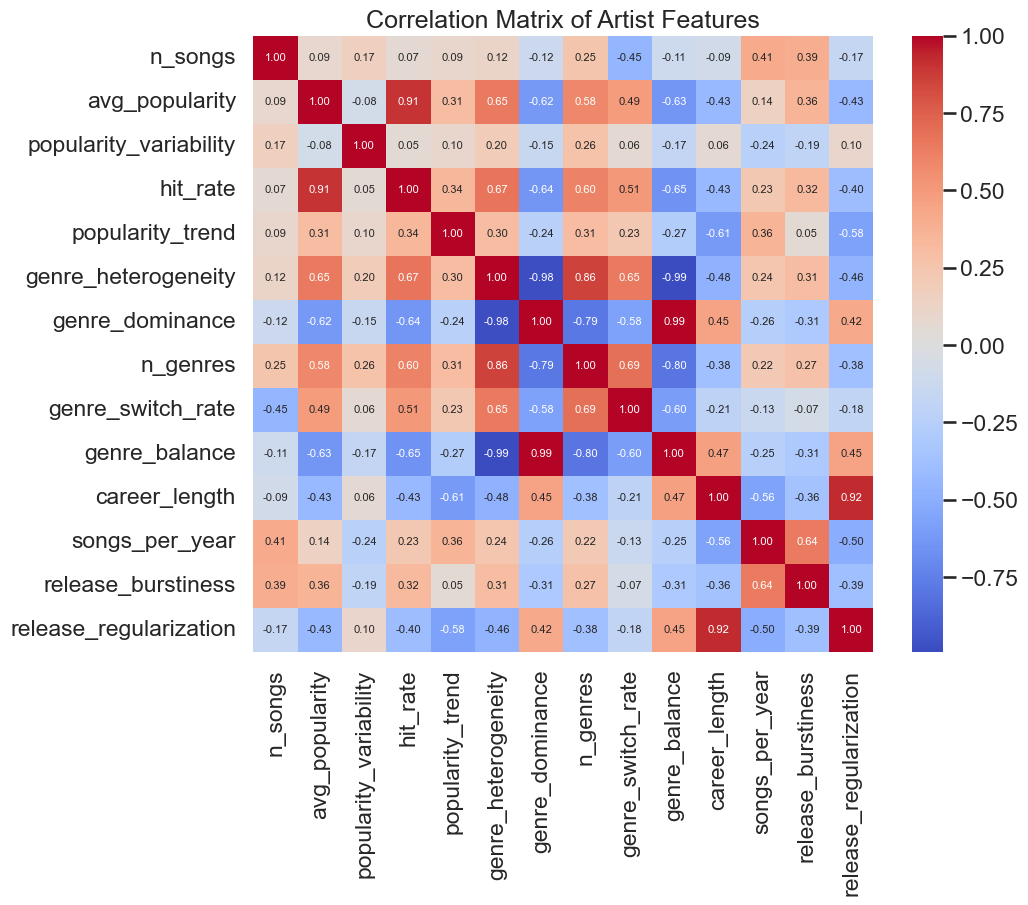

In [53]:
plt.figure(figsize=(10,8))
sns.heatmap(
    artist_features_50plus.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 8}   # smaller numbers
)
plt.title("Correlation Matrix of Artist Features")
plt.show()

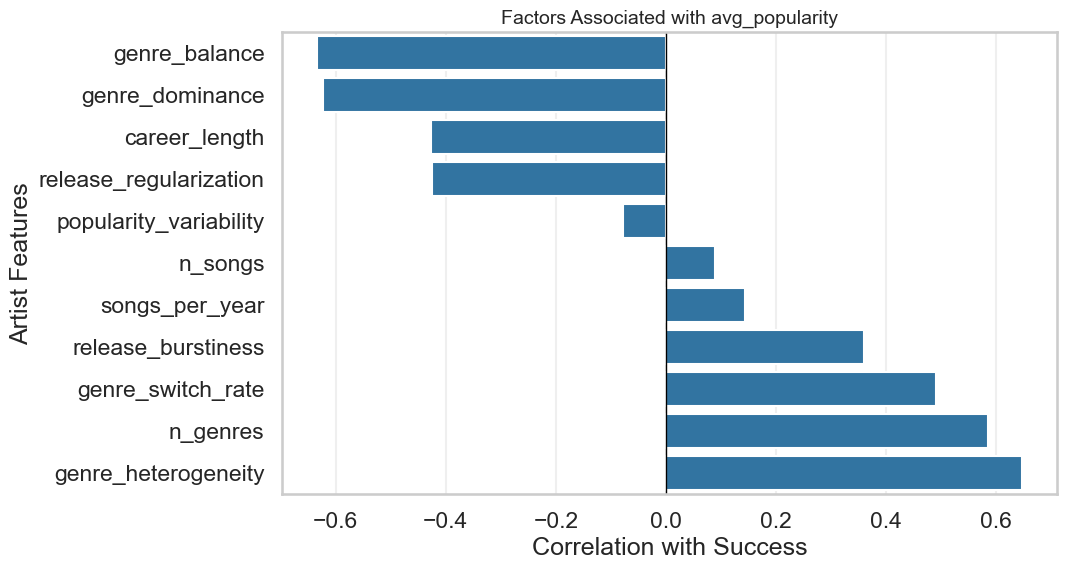

In [ ]:
# Define success variable
success_var = 'avg_popularity'

excluded_vars = [
    'avg_popularity',
    'hit_rate',
    'popularity_trend',
    'popularity_variability'
]

# Compute correlations with success
corr_success = (
    artist_features_50plus
    .select_dtypes(include='number')
    .corr()[success_var]
    .drop(excluded_vars)
    .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_success.values, y=corr_success.index)

plt.title(f"Factors Associated with {success_var}", fontsize=14)
plt.xlabel("Correlation with Success")
plt.ylabel("Artist Features")
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)

plt.show()

Ce graphique permet d’identifier les facteurs les plus associés au succès global d’un artiste. 

* Diversité de genre : On observe que la diversité de genre est le facteur le plus fortement associé au succès, avec de fortes corrélations positives pour `genre_heterogeneity`, `n_genres`, `genre_switch_rate`, et négatives pour `genre_balance` et `genre_dominance`. Les artistes qui explorent plusieurs genres musicaux ont tendance à être plus populaires en moyenne. Ainsi, la capacité à diversifier son style semble constituer un levier important de succès.

* Intensité de production : Les variables liées à l’activité de production présentent également des corrélations positives avec la popularité moyenne, notamment `release_burstiness`, `songs_per_year` et `n_songs`. Cela suggère que les artistes qui publient fréquemment des chansons ou qui connaissent des périodes de forte activité tendent à être plus populaires.

* Stabilité de carrière : On observe une corrélation négative entre la durée de carrière `career_length` et la popularité moyenne. Cela peut indiquer que les artistes ayant une carrière très longue ne sont pas nécessairement les plus populaires dans notre échantillon, possiblement en raison de l’évolution des tendances musicales ou de la difficulté à maintenir un niveau élevé de popularité sur une longue période.

* Régularité des sorties : La variable `release_regularization` présente également une corrélation négative avec la popularité moyenne. Cela suggère que les artistes qui publient de manière très régulière ne sont pas nécessairement les plus populaires, tandis que des sorties plus irrégulières ou concentrées dans le temps peuvent être associées à des périodes de succès plus marqué.

In [2]:
### PCA 

cols_to_exclude = [
    'track_artist',
    'avg_popularity',
    'hit_rate',
    'popularity_trend',
    'popularity_variability'
]

# 1. Select numeric variables
X = (
    artist_features_50plus
    .select_dtypes(include='number')
    .drop(columns=cols_to_exclude, errors='ignore')
)

# 2. Handle missing values
X = X.fillna(X.median())

# 3. Scale variables (CRUCIAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker='o'
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.grid(alpha=0.3)

plt.show()



cum_var = np.cumsum(explained_var)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var) + 1),
    cum_var,
    marker='o'
)

plt.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    label='80% variance'
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.legend()
plt.grid(alpha=0.3)

plt.show()





### PROJECTED PTS
plt.figure(figsize=(18, 5))

c = artist_features_50plus['avg_popularity']

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c, alpha=0.7)
plt.title("PC1 vs PC2")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 2], c=c, alpha=0.7)
plt.title("PC1 vs PC3")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 1], X_pca[:, 2], c=c, alpha=0.7)
plt.title("PC2 vs PC3")
plt.xlabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



# CIRCLE VAR

loadings = (
    pca.components_.T *
    np.sqrt(pca.explained_variance_)
)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(loadings.shape[1])],
    index=X.columns
)


plt.figure(figsize=(9,9))
plt.axhline(0)
plt.axvline(0)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

# Unit circle
circle = plt.Circle((0,0), 1, fill=False)
plt.gca().add_artist(circle)

for var in loadings_df.index:
    x = loadings_df.loc[var, 'PC1']
    y = loadings_df.loc[var, 'PC2']
    plt.arrow(
        0,
        0,
        x,
        y,
        head_width=0.03,
        head_length=0.03,
        linewidth=1,
        color="tomato",
        alpha=0.8
    )
    plt.text(
        x * 1.12,
        y * 1.12,
        var,
        fontsize=10,
        ha='center'
    )

plt.title("Correlation Circle (PC1 vs PC2)")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


NameError: name 'artist_features_50plus' is not defined

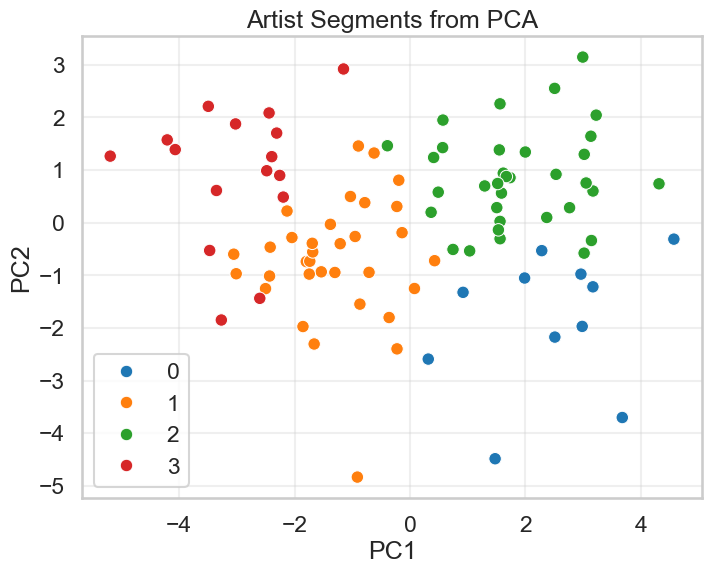

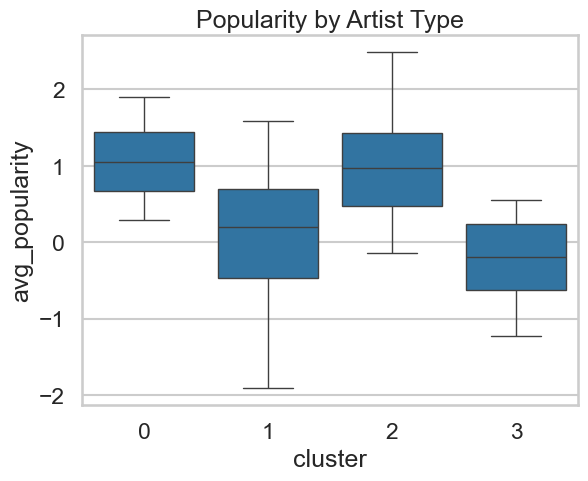

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=0
)

clusters = kmeans.fit_predict(X_pca[:, :3])

artist_features_50plus['cluster'] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="tab10"
)

plt.title("Artist Segments from PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(alpha=0.3)
plt.show()



sns.boxplot(
    data=artist_features_50plus,
    x='cluster',
    y='avg_popularity'
)

plt.title("Popularity by Artist Type")
plt.show()


#### CLUSTERING ARTISTES

In [58]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Copy dataset
cluster_data = artist_features.copy()

# Remove artist name
X = cluster_data.drop(columns=['track_artist'])

# Handle missing values
X = X.fillna(X.median())

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)




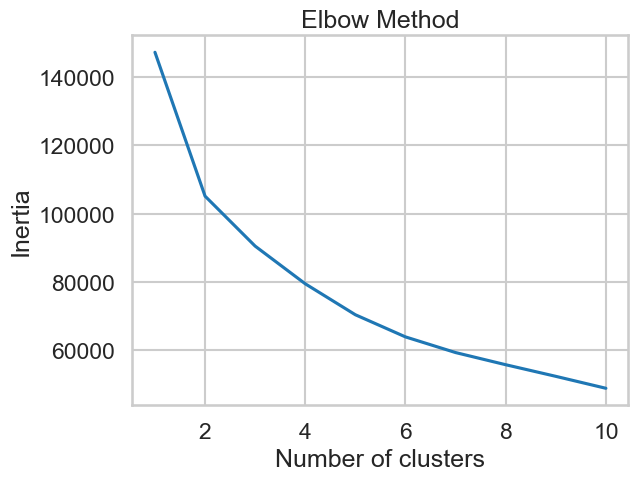

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(1, 11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure()

plt.plot(k_range, inertia)

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [60]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

artist_features['cluster'] = cluster_labels

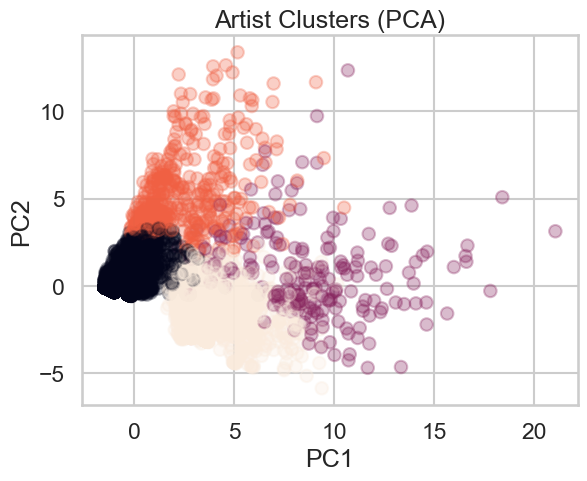

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure()

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=artist_features['cluster'],
    alpha = 0.3

)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Artist Clusters (PCA)")

plt.show()

In [62]:
cluster_summary = (
    artist_features
    .drop(columns=['track_artist'])
    .groupby('cluster')
    .mean(numeric_only=True)
    .round(2)
)



cluster_sizes = artist_features['cluster'].value_counts().sort_index()
print(f"Cluster sizes : {cluster_sizes}")

cluster_summary['n_artists'] = cluster_sizes

cluster_summary

Cluster sizes : cluster
0    8543
1     202
2     397
3    1374
Name: count, dtype: int64


,n_songs,avg_popularity,popularity_variability,hit_rate,popularity_trend,genre_heterogeneity,genre_dominance,n_genres,genre_switch_rate,genre_balance,career_length,songs_per_year,release_burstiness,release_regularization,n_artists
cluster,,,,,,,,,,,,,,,
0,1.70,-0.3,0.39,0.10,0.09,0.00,1.00,1.00,0.82,0.41,0.55,1.25,0.61,1.54,8543
1,33.60,0.5,0.85,0.55,0.34,0.83,0.66,3.55,0.14,0.26,6.85,6.27,5.71,2.38,202
2,11.02,-0.1,0.80,0.27,-0.32,0.16,0.93,1.42,0.21,0.38,22.96,0.52,1.29,13.15,397
3,4.62,0.2,0.52,0.32,0.10,0.72,0.59,2.27,0.67,0.26,2.77,1.95,0.93,2.02,1374


## V. Création de playlists

## CONCLUSION

In [63]:
target = 'track_popularity'
features = quant_cols_gauss.copy()
print(features)
features.remove(target)
all_vars = [target] + features
data_scaled = data

pca = PCA(n_components=2)
pca.fit(data_scaled)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=all_vars)

plt.figure(figsize=(10, 10))
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='grey', ls='--', alpha=0.5)
plt.axvline(0, color='grey', ls='--', alpha=0.5)

circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='-', alpha=0.1)
plt.gca().add_artist(circle)

for var in all_vars:
    x = loadings_df.loc[var, 'PC1']
    y = loadings_df.loc[var, 'PC2']
    
    # Mise en évidence de la popularité
    is_pop = (var == target)
    color = 'dodgerblue' if is_pop else 'tomato'
    width = 2.5 if is_pop else 1
    
    plt.arrow(0, 0, x, y, head_width=0.04, head_length=0.04, 
              color=color, linewidth=width, alpha=0.8)
    
    # Label
    plt.text(x*1.15, y*1.15, var, color='black', 
             fontweight='bold' if is_pop else 'normal', fontsize=11, ha='center')

plt.title("Cercle des Corrélations : Déterminants de la Popularité", fontsize=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

['loudness_yeo', 'speechiness_yeo', 'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'track_popularity', 'danceability', 'energy', 'valence', 'tempo', 'duration_ms']


ValueError: could not convert string to float: "I Don't Care (with Justin Bieber) - Loud Luxury Remix"